# 03 — Product Category Revenue Analysis
Break down sales and profit by product category and sub-category to guide assortment decisions.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("03 — Product Category Revenue Analysis")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 16:58:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
cat_df = spark.sql('''
    SELECT p.category,
           ROUND(SUM(oi.sales),  2) AS total_sales,
           ROUND(SUM(oi.profit), 2) AS total_profit
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category ORDER BY total_sales DESC
''').toPandas()

sub_df = spark.sql('''
    SELECT p.category, p.sub_category,
           ROUND(SUM(oi.sales),  2) AS total_sales,
           ROUND(SUM(oi.profit), 2) AS total_profit
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category, p.sub_category ORDER BY total_sales DESC
''').toPandas()
print(sub_df.head(10))

          category sub_category  total_sales  total_profit
0       Technology       Phones    329753.09      44447.88
1        Furniture       Chairs    328449.10      26590.17
2  Office Supplies      Storage    216803.21      21527.91
3        Furniture       Tables    206965.53     -17725.48
4  Office Supplies      Binders    199905.72      29983.02
5       Technology     Machines    189238.63       3384.76
6       Technology  Accessories    167380.32      41936.64
7       Technology      Copiers    149528.03      55617.82
8        Furniture    Bookcases    114880.00      -3472.56
9  Office Supplies   Appliances    107532.16      18138.01


## Visualisation

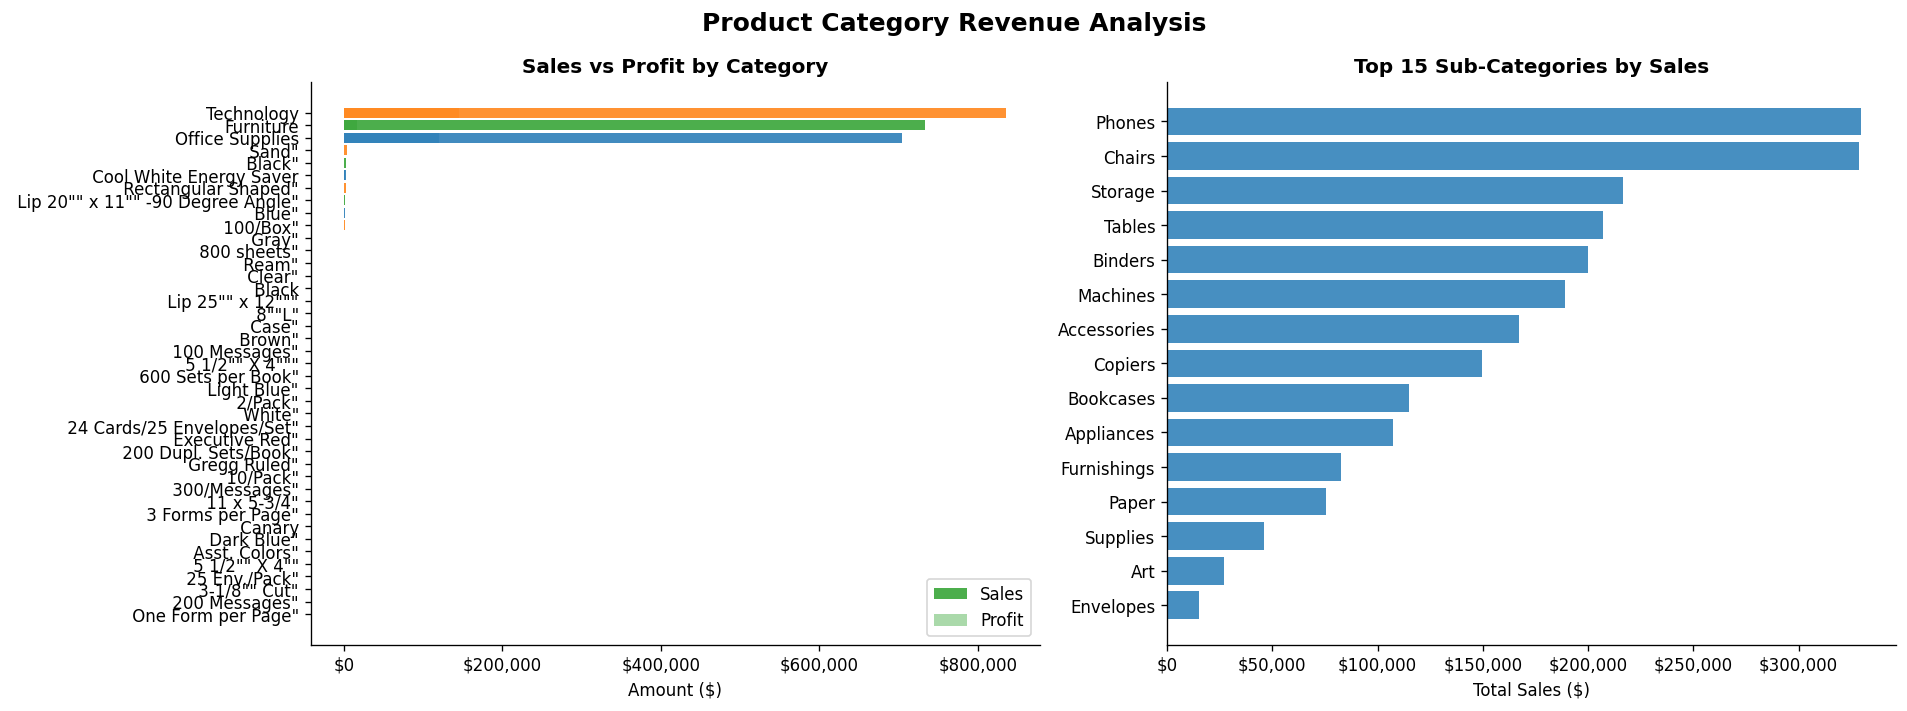

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/03_product_category.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cat_colors = ["#1f77b4","#ff7f0e","#2ca02c"]

axes[0].barh(cat_df["category"][::-1], cat_df["total_sales"][::-1],  color=cat_colors[::-1], alpha=0.85, label="Sales")
axes[0].barh(cat_df["category"][::-1], cat_df["total_profit"][::-1], color=cat_colors[::-1], alpha=0.4,  label="Profit")
axes[0].set_title("Sales vs Profit by Category", fontweight="bold"); axes[0].set_xlabel("Amount ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}")); axes[0].legend()

top15 = sub_df.head(15)
short = [n[:30]+"…" if len(n)>30 else n for n in top15["sub_category"]]
axes[1].barh(short[::-1], top15["total_sales"][::-1], color="#1f77b4", alpha=0.82)
axes[1].set_title("Top 15 Sub-Categories by Sales", fontweight="bold"); axes[1].set_xlabel("Total Sales ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

plt.suptitle("Product Category Revenue Analysis", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/03_product_category.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/03_product_category.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
